In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("flood dataset.xlsx")
df.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [ ]:
print(df["flood"].value_counts())

flood
0    99
1    16
Name: count, dtype: int64


In [ ]:
df.columns

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='object')

In [ ]:
df.shape

(115, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [ ]:
df.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


In [ ]:
df.isnull().sum()

,0
Temp,0
Humidity,0
Cloud Cover,0
ANNUAL,0
Jan-Feb,0
Mar-May,0
Jun-Sep,0
Oct-Dec,0
avgjune,0
sub,0


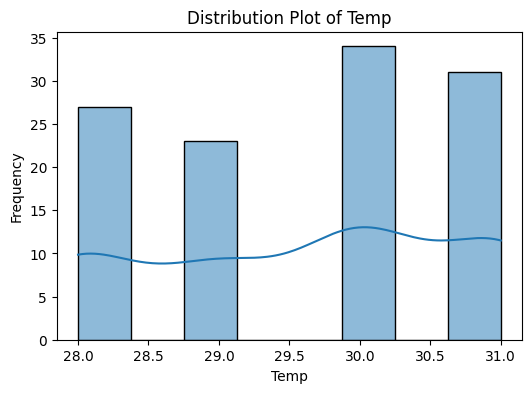

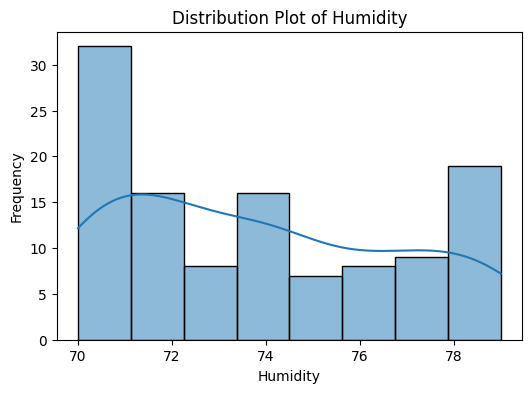

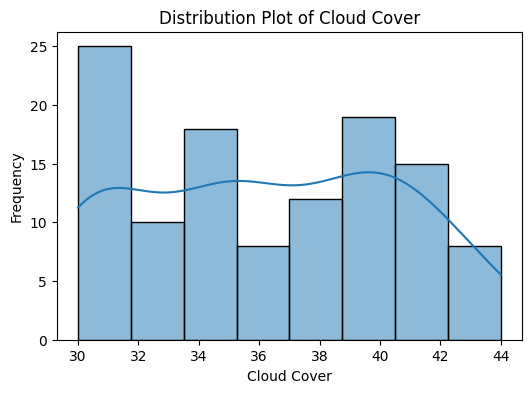

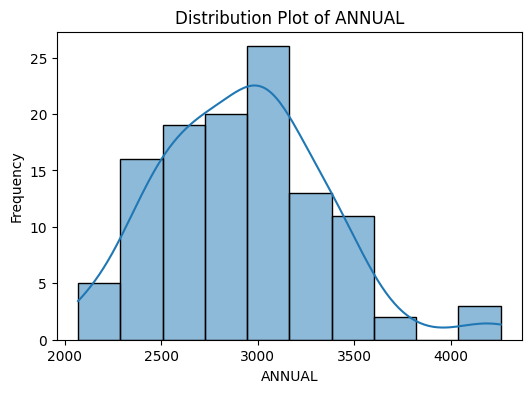

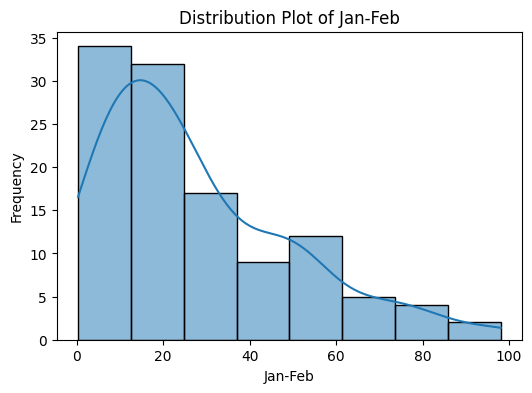

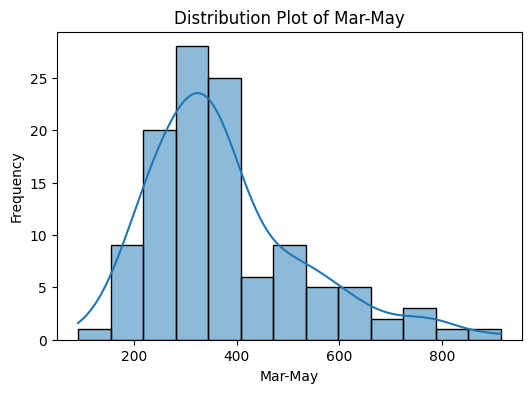

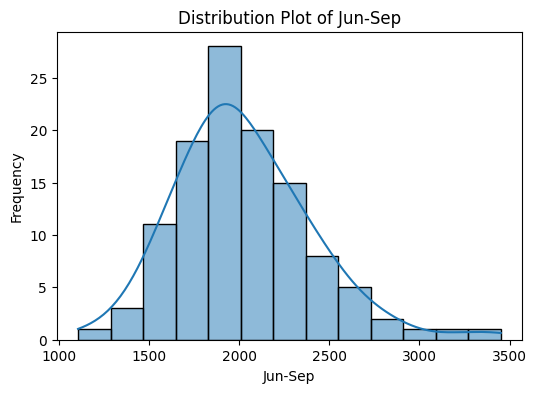

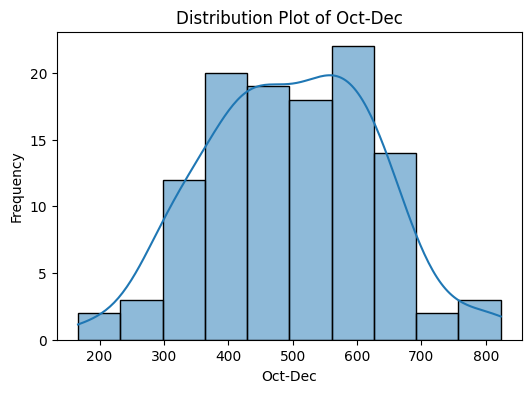

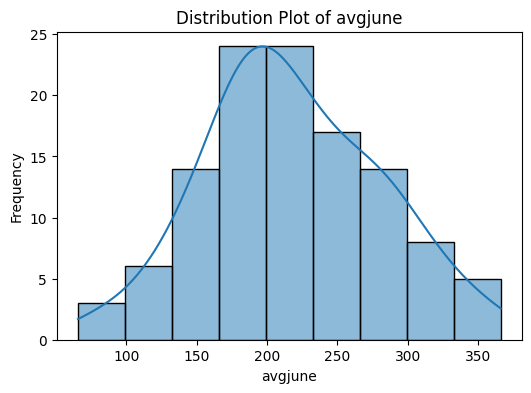

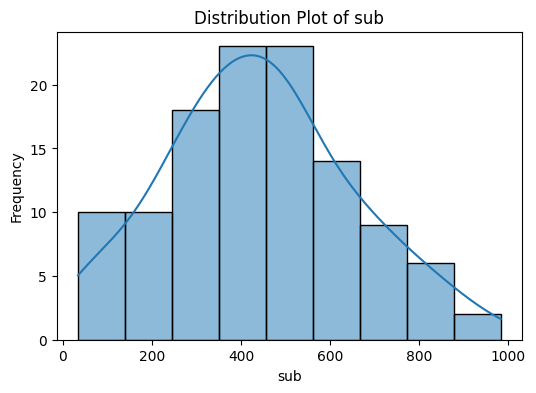

In [ ]:
num_cols = df.select_dtypes(include='number').columns.drop('flood')
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

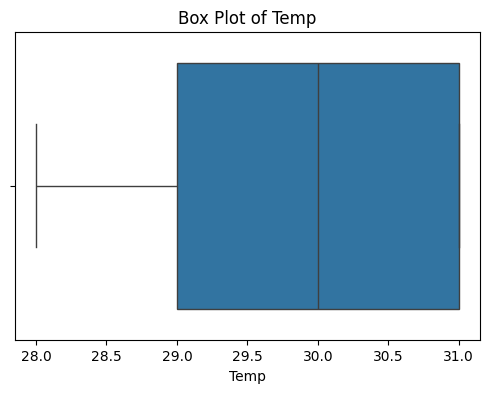

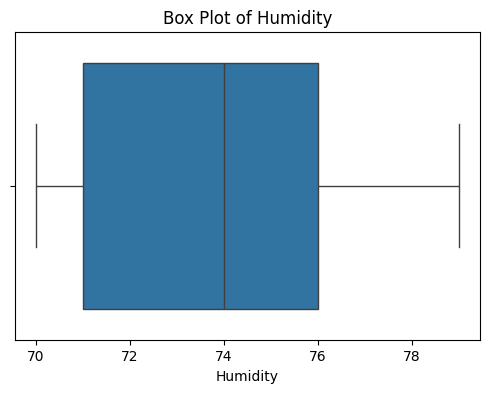

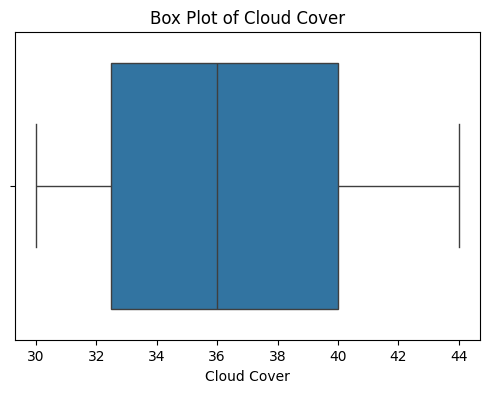

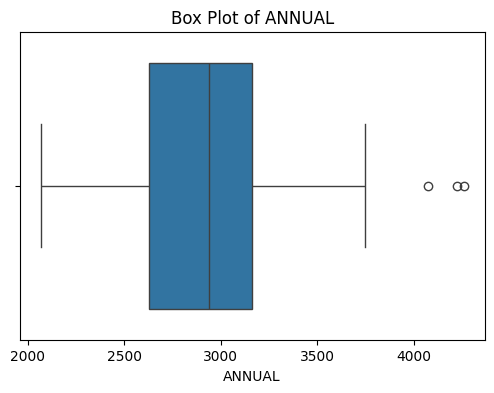

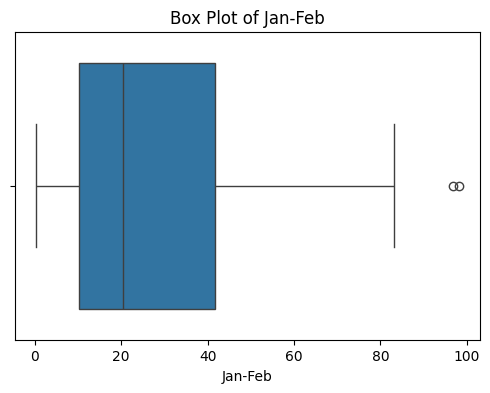

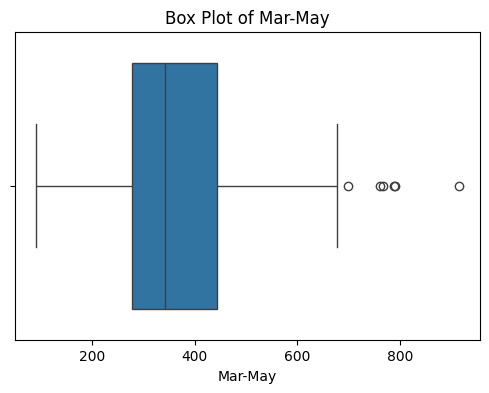

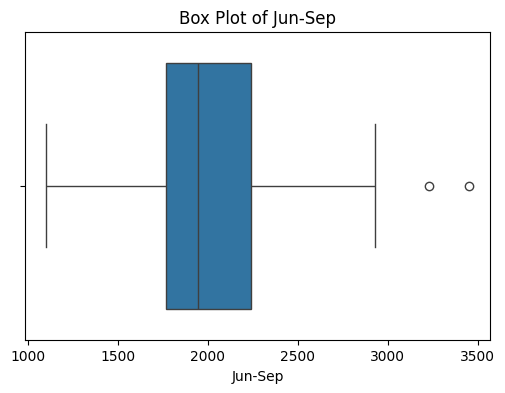

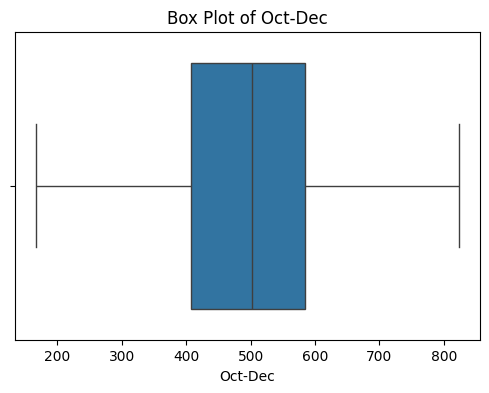

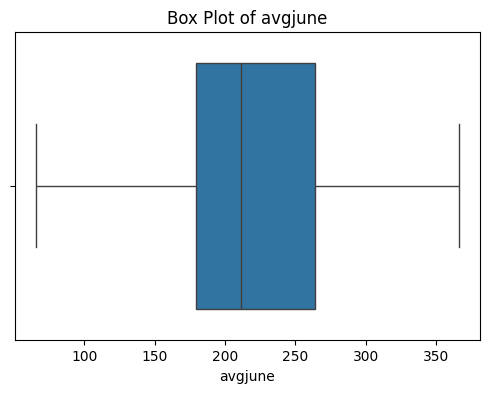

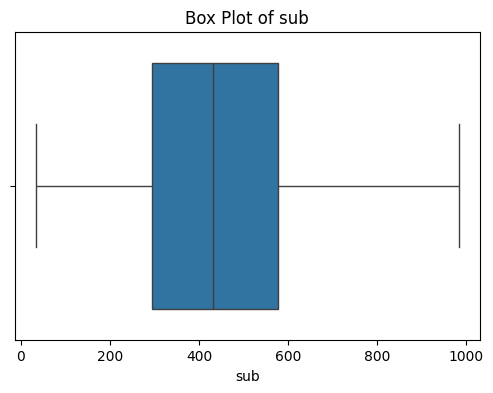

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
    plt.show()

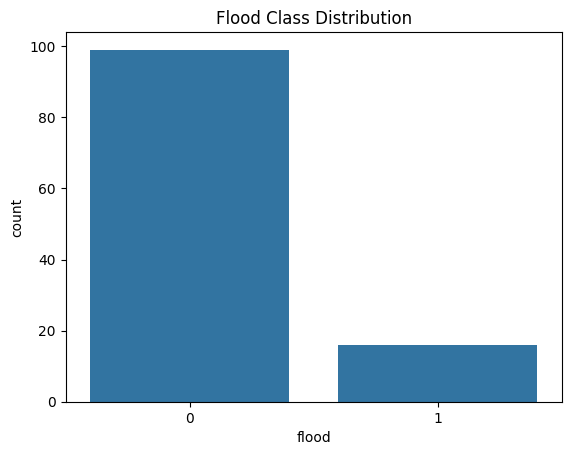

In [ ]:
sns.countplot(x='flood', data=df)
plt.title("Flood Class Distribution")
plt.show()

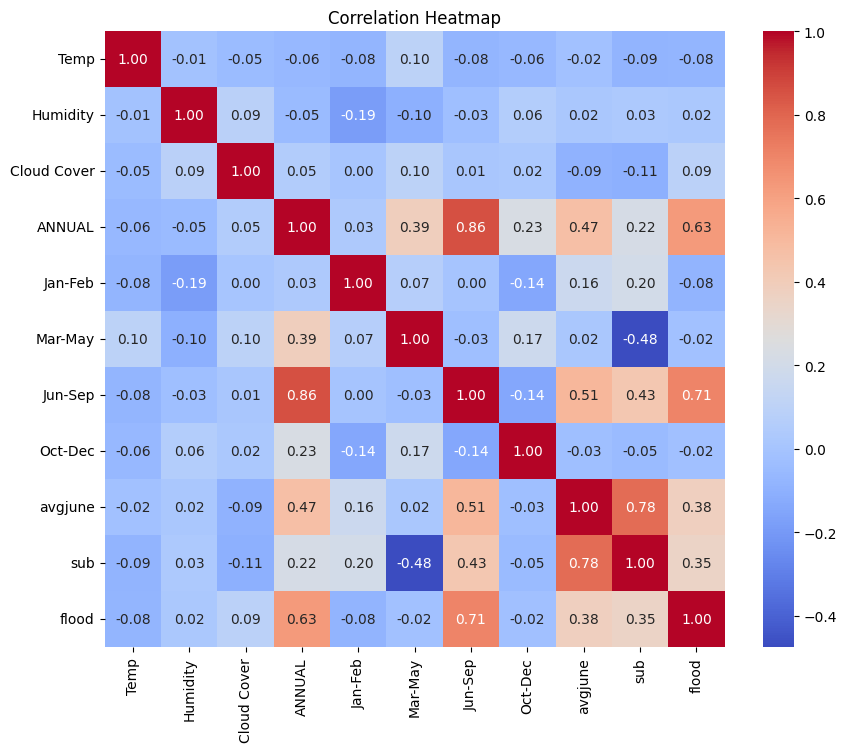

In [ ]:

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.isnull().any()

,0
Temp,False
Humidity,False
Cloud Cover,False
ANNUAL,False
Jan-Feb,False
Mar-May,False
Jun-Sep,False
Oct-Dec,False
avgjune,False
sub,False


In [ ]:
x = df.drop('flood', axis=1)
y = df['flood']
print(f"Features (X):")
print(x.head())
print(f"\nTarget (y):")
print(y.head())

Features (X):
   Temp  Humidity  Cloud Cover  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  \
0    29        70           30  3248.6     73.4    386.2   2122.8    666.1   
1    28        75           40  3326.6      9.3    275.7   2403.4    638.2   
2    28        75           42  3271.2     21.7    336.3   2343.0    570.1   
3    29        71           44  3129.7     26.7    339.4   2398.2    365.3   
4    31        74           40  2741.6     23.4    378.5   1881.5    458.1   

      avgjune    sub  
0  274.866667  649.9  
1  130.300000  256.4  
2  186.200000  308.9  
3  366.066667  862.5  
4  283.400000  586.9  

Target (y):
0    0
1    1
2    0
3    0
4    0
Name: flood, dtype: int64


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
# Apply Label Encoding if categorical columns exist
if len(categorical_cols) > 0:
    le = LabelEncoder()
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col])
    print("Categorical columns encoded successfully.")
else:
    print("No categorical columns found. Encoding not required.")

No categorical columns found. Encoding not required.


In [ ]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

# Create scaler
scaler = StandardScaler()

# Fit and transform training data
X_train = scaler.fit_transform(X_train)

# Transform testing data
X_test = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
dtree = DecisionTreeClassifier(random_state=42)

rf = RandomForestClassifier(random_state=42)

knn = KNeighborsClassifier()

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Decision Tree trained successfully.
Random Forest trained successfully.
KNN trained successfully.
XGBoost trained successfully.


In [ ]:
print(model.classes_)

[0 1]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    print("=" * 50)
    print(name)
    print("=" * 50)

    acc = accuracy_score(y_test, y_pred)
    accuracy[name] = acc

    print("Accuracy:")
    print(acc)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

best_model = max(accuracy, key=accuracy.get)

print("Best Model :", best_model)

print("Accuracy :", accuracy[best_model])

Decision Tree
Accuracy:
1.0

Confusion Matrix:
[[23  0]
 [ 0  6]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00         6

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29

Random Forest
Accuracy:
1.0

Confusion Matrix:
[[23  0]
 [ 0  6]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00         6

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29

KNN
Accuracy:
0.8620689655172413

Confusion Matrix:
[[23  0]
 [ 4  2]]

Classification Report:
              precision    recall  f1-score   support

           0    

In [ ]:
print(best_model)

Decision Tree


In [ ]:
import joblib

joblib.dump(models[best_model], "floods.save")

joblib.dump(scaler, "transform.save")

['transform.save']

In [ ]:
import joblib

model = joblib.load("floods.save")

scaler = joblib.load("transform.save")